In [11]:
# import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree

In [28]:
# data loading
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

In [29]:
# Train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [30]:
rf = RandomForestClassifier(n_estimators=50,  # number of trees
                            max_depth=None,  # daraxt chuqurligi
                            )

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [31]:
# Evaluation
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.911
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



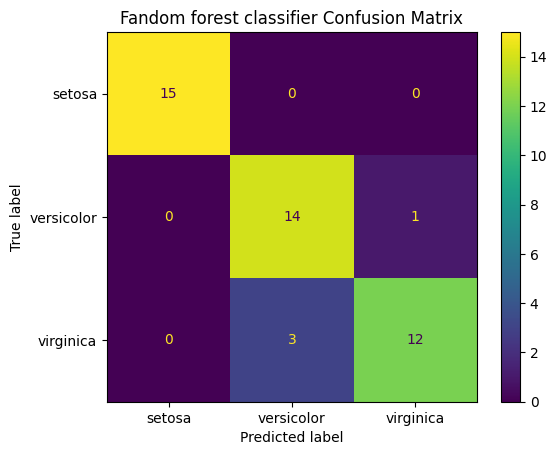

In [32]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot()
plt.title('Fandom forest classifier Confusion Matrix')
plt.show()

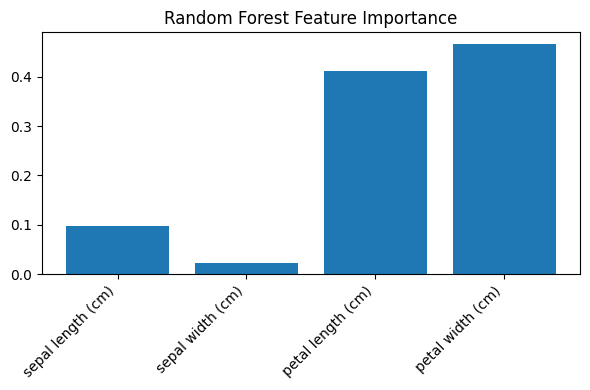

In [36]:
# Feature importance graph
plt.figure(figsize=(6, 4))
plt.bar(range(len(feature_names)), rf.feature_importances_)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

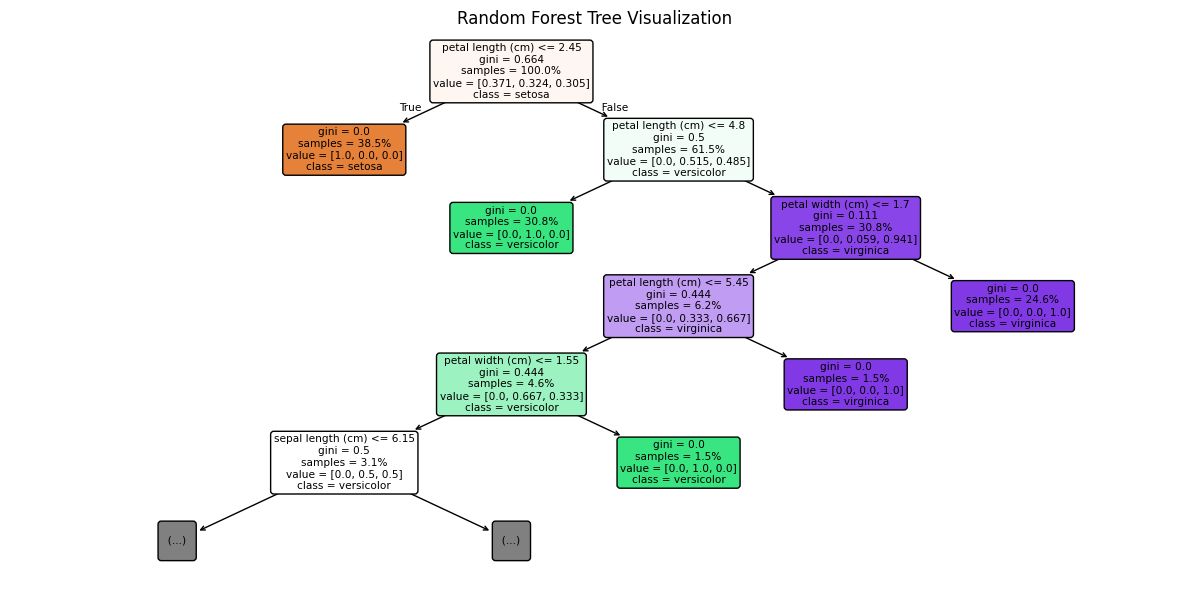

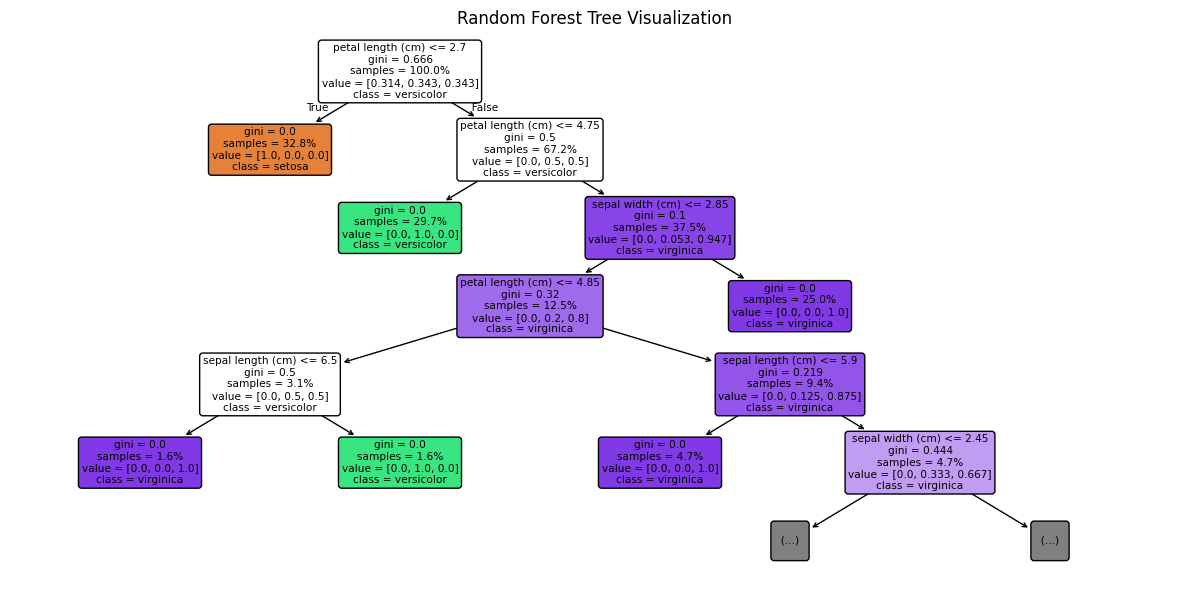

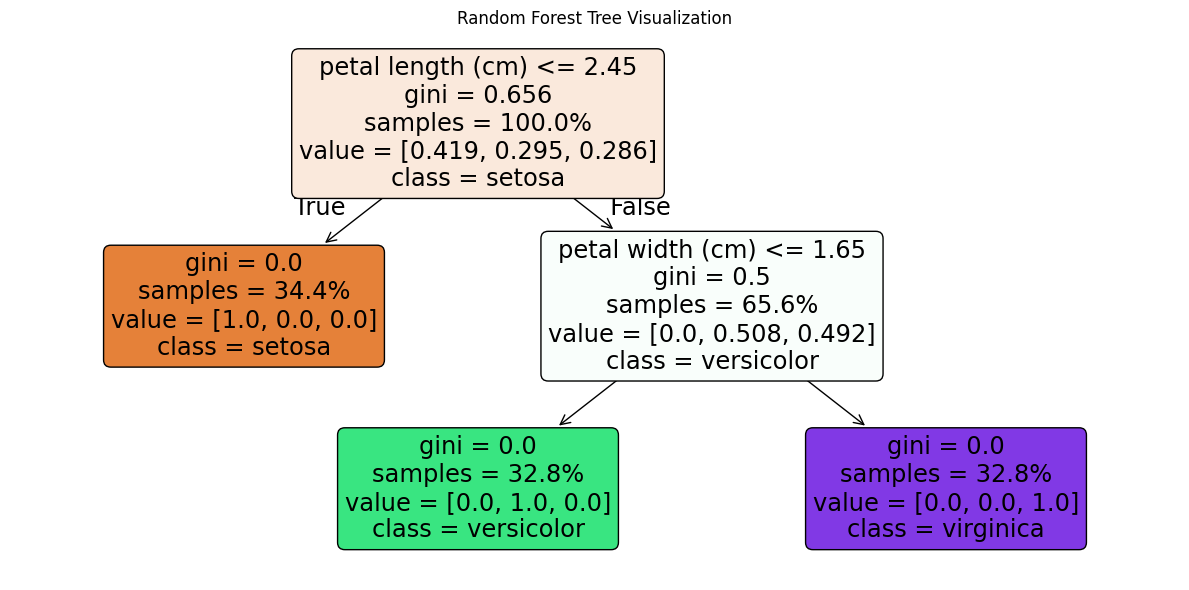

None


In [55]:
# Trees visualization

def visualize_forest_trees(forest, feature_names=feature_names, class_names=class_names, n=3, max_depth=5):
  n = min(n, len(forest.estimators_))
  for i in range(n):
    estimator = forest.estimators_[i]
    plt.figure(figsize=(12, 6))
    plot_tree(
        estimator,
        feature_names=feature_names,
        class_names=class_names,
        filled = True,
        rounded = True,
        impurity = True,
        proportion = True,
        max_depth = max_depth
    )
    plt.title('Random Forest Tree Visualization')
    plt.tight_layout()
    plt.show()


print(visualize_forest_trees(rf))

#visualize_forest_trees(rf, feature_names, class_names, n=3, max_depth=3)